# Student Dropout Prediction - Exploratory Data Analysis

This notebook explores the student dropout dataset under the current MVP scope. The analysis keeps only Graduate and Dropout records, uses candidate pre-acceptance features, and converts categorical codes into readable labels before visualization.

In [25]:
# Import libraries used for data loading, transformation, and visualization.
from pathlib import Path
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Data

This section resolves the project paths, loads the raw dataset, and checks the raw shape before any filtering is applied.

In [26]:
# Resolve paths so the notebook works from either the project root or the notebooks folder.
current_path = Path.cwd()

if (current_path / "data" / "raw" / "dataset.csv").exists():
    PROJECT_ROOT = current_path
else:
    PROJECT_ROOT = current_path.parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "dataset.csv"
FEATURE_CONFIG_PATH = PROJECT_ROOT / "app" / "feature_config.json"
MVP_READABLE_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "mvp_features_readable.csv"
RAW_READABLE_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "raw_features_readable.csv"
MVP_NUMERIC_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "mvp_features_numeric.csv"

print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())
print("Feature config path:", FEATURE_CONFIG_PATH)
print("Feature config exists:", FEATURE_CONFIG_PATH.exists())
print("Readable MVP data path:", MVP_READABLE_DATA_PATH)
print("Readable raw full-feature data path:", RAW_READABLE_DATA_PATH)

Project root: e:\Projects\student-dropout-prediction-ml
Dataset path: e:\Projects\student-dropout-prediction-ml\data\raw\dataset.csv
Dataset exists: True
Feature config path: e:\Projects\student-dropout-prediction-ml\app\feature_config.json
Feature config exists: True
Readable MVP data path: e:\Projects\student-dropout-prediction-ml\data\processed\mvp_features_readable.csv
Readable raw full-feature data path: e:\Projects\student-dropout-prediction-ml\data\processed\raw_features_readable.csv


In [27]:
# Load the raw dataset.
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (4424, 35)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [28]:
# Run a quick health check on the raw dataset.
print("Raw dataset shape:", df.shape)
print("Raw duplicate rows:", df.duplicated().sum())
print("Raw missing values:", df.isnull().sum().sum())

Raw dataset shape: (4424, 35)
Raw duplicate rows: 0
Raw missing values: 0


In [29]:
# Select Pre-Acceptance MVP Candidate Features
# The MVP scope excludes post-acceptance variables, including daytime/evening attendance,
# semester academic performance variables, macroeconomic indicators, application mode, and application order.
# Categorical values are converted with app/feature_config.json so charts show labels, not raw codes.

post_acceptance_features = [
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder"
]

academic_semester_features = [
    col for col in df.columns
    if "Curricular units" in col
]

excluded_for_mvp_interpretability = [
    "Mother's occupation",
    "Father's occupation",
    "Unemployment rate",
    "Inflation rate",
    "GDP",
    "Application mode",
    "Application order"
]

candidate_mvp_features = [
    "Marital status",
    "Course",
    "Previous qualification",
    "Mother's qualification",
    "Father's qualification",
    "Displaced",
    "Educational special needs",
    "Gender",
    "Age at enrollment",
    "International"
]

selected_columns = candidate_mvp_features + ["Target"]
missing_selected_columns = [col for col in selected_columns if col not in df.columns]

if missing_selected_columns:
    raise ValueError(f"Missing selected columns: {missing_selected_columns}")

with open(FEATURE_CONFIG_PATH, "r", encoding="utf-8") as file:
    feature_config = json.load(file)

value_mappings = feature_config.get("value_mappings", {})


def normalize_category_value(value):
    try:
        numeric_value = float(value)
        if numeric_value.is_integer():
            return str(int(numeric_value))
        return str(numeric_value)
    except (TypeError, ValueError):
        return str(value)


def map_encoded_value(feature, value):
    mapping = value_mappings.get(feature, {})
    key = normalize_category_value(value)
    return mapping.get(key, f"Unknown / unmapped code: {key}")


excluded_columns = [col for col in df.columns if col not in selected_columns]
df_mvp_encoded = df[selected_columns].copy()
df_mvp = df_mvp_encoded.copy()

categorical_display_features = [
    feature for feature in candidate_mvp_features
    if feature != "Age at enrollment"
]

for feature in categorical_display_features:
    df_mvp[feature] = df_mvp[feature].apply(
        lambda value, feature=feature: map_encoded_value(feature, value)
    )

print("Original dataset shape:", df.shape)
print("MVP EDA dataset shape before target filtering:", df_mvp.shape)
print("Selected MVP candidate features:", len(candidate_mvp_features))
print("Excluded columns:", len(excluded_columns))
print("Categorical features converted to text:", len(categorical_display_features))

excluded_columns

Original dataset shape: (4424, 35)
MVP EDA dataset shape before target filtering: (4424, 11)
Selected MVP candidate features: 10
Excluded columns: 24
Categorical features converted to text: 9


['Application mode',
 'Application order',
 'Daytime/evening attendance',
 'Nacionality',
 "Mother's occupation",
 "Father's occupation",
 'Debtor',
 'Tuition fees up to date',
 'Scholarship holder',
 'Curricular units 1st sem (credited)',
 'Curricular units 1st sem (enrolled)',
 'Curricular units 1st sem (evaluations)',
 'Curricular units 1st sem (approved)',
 'Curricular units 1st sem (grade)',
 'Curricular units 1st sem (without evaluations)',
 'Curricular units 2nd sem (credited)',
 'Curricular units 2nd sem (enrolled)',
 'Curricular units 2nd sem (evaluations)',
 'Curricular units 2nd sem (approved)',
 'Curricular units 2nd sem (grade)',
 'Curricular units 2nd sem (without evaluations)',
 'Unemployment rate',
 'Inflation rate',
 'GDP']

In [30]:
# Preview Readable MVP Dataset
# Keep selected MVP features and original target classes temporarily so the next step can remove Enrolled.
# The processed CSV is saved after Enrolled records are removed.

print("Readable MVP dataset shape before removing Enrolled:", df_mvp.shape)

df_mvp.head()


Readable MVP dataset shape before removing Enrolled: (4424, 11)


,Marital status,Course,Previous qualification,Mother's qualification,Father's qualification,Displaced,Educational special needs,Gender,Age at enrollment,International,Target
0,Single,Animation and Multimedia Design,Secondary education,Basic education 3rd cycle,Other 11th year schooling,Yes,No,Male,20,No,Dropout
1,Single,Tourism,Secondary education,Secondary education,Higher education - degree,Yes,No,Male,19,No,Graduate
2,Single,Communication Design,Secondary education,Basic education 1st cycle,Basic education 1st cycle,Yes,No,Male,19,No,Dropout
3,Single,Journalism and Communication,Secondary education,Basic education 2nd cycle,Basic education 1st cycle,Yes,No,Female,20,No,Graduate
4,Married,Social Service Evening Program,Secondary education,Basic education 1st cycle,Basic education 2nd cycle,No,No,Female,45,No,Graduate


In [31]:
# Save Readable Raw Full-Feature Dataset
# Keep all original raw columns, but convert categorical codes with available readable mappings.
# Some raw columns use dense 1..N codes, while their reference mappings use original dataset codes.

provided_raw_value_mappings = {
    "Application order": {
        "0": "First choice",
        "1": "Second choice",
        "2": "Third choice",
        "3": "Fourth choice",
        "4": "Fifth choice",
        "5": "Sixth choice",
        "6": "Seventh choice",
        "7": "Eighth choice",
        "8": "Ninth choice",
        "9": "Last choice",
    },
    "Daytime/evening attendance": {
        "0": "Evening",
        "1": "Daytime",
    },
    "Nacionality": {
        "1": "Portuguese",
        "2": "German",
        "6": "Spanish",
        "11": "Italian",
        "13": "Dutch",
        "14": "English",
        "17": "Lithuanian",
        "21": "Angolan",
        "22": "Cape Verdean",
        "24": "Guinean",
        "25": "Mozambican",
        "26": "Santomean",
        "32": "Turkish",
        "41": "Brazilian",
        "62": "Romanian",
        "100": "Moldova",
        "101": "Mexican",
        "103": "Ukrainian",
        "105": "Russian",
        "108": "Cuban",
        "109": "Colombian",
    },
    "Mother's occupation": {
        "0": "Student",
        "1": "Representatives of the Legislative Power and Executive Bodies, Directors, Directors and Executive Managers",
        "2": "Specialists in Intellectual and Scientific Activities",
        "3": "Intermediate Level Technicians and Professions",
        "4": "Administrative staff",
        "5": "Personal Services, Security and Safety Workers and Sellers",
        "6": "Farmers and Skilled Workers in Agriculture, Fisheries and Forestry",
        "7": "Skilled Workers in Industry, Construction and Craftsmen",
        "8": "Installation and Machine Operators and Assembly Workers",
        "9": "Unskilled Workers",
        "10": "Armed Forces Professions",
        "90": "Other Situation",
        "99": "Blank",
        "122": "Health professionals",
        "123": "Teachers",
        "125": "Specialists in Information and Communication Technologies",
        "131": "Intermediate Level Science and Engineering Technicians and Professions",
        "132": "Intermediate Level Health Technicians and Professionals",
        "134": "Intermediate Level Technicians from Legal, Social, Sports, Cultural and Similar Services",
        "141": "Office Workers, Secretaries in General and Data Processing Operators",
        "143": "Data, Accounting, Statistical, Financial Services and Registry-Related Operators",
        "144": "Other Administrative Support Staff",
        "151": "Personal Service Workers",
        "152": "Sellers",
        "153": "Personal Care Workers and Similar",
        "171": "Skilled Construction Workers and Similar, Except Electricians",
        "173": "Skilled Workers in Printing, Precision Instrument Manufacturing, Jewelers, Artisans and Similar",
        "175": "Workers in Food Processing, Woodworking, Clothing and Other Industries and Crafts",
        "191": "Cleaning Workers",
        "192": "Unskilled Workers in Agriculture, Animal Production, Fisheries and Forestry",
        "193": "Unskilled Workers in Extractive Industry, Construction, Manufacturing and Transport",
        "194": "Meal Preparation Assistants",
    },
    "Father's occupation": {
        "0": "Student",
        "1": "Representatives of the Legislative Power and Executive Bodies, Directors, Directors and Executive Managers",
        "2": "Specialists in Intellectual and Scientific Activities",
        "3": "Intermediate Level Technicians and Professions",
        "4": "Administrative staff",
        "5": "Personal Services, Security and Safety Workers and Sellers",
        "6": "Farmers and Skilled Workers in Agriculture, Fisheries and Forestry",
        "7": "Skilled Workers in Industry, Construction and Craftsmen",
        "8": "Installation and Machine Operators and Assembly Workers",
        "9": "Unskilled Workers",
        "10": "Armed Forces Professions",
        "90": "Other Situation",
        "99": "Blank",
        "101": "Armed Forces Officers",
        "102": "Armed Forces Sergeants",
        "103": "Other Armed Forces Personnel",
        "112": "Directors of Administrative and Commercial Services",
        "114": "Hotel, Catering, Trade and Other Services Directors",
        "121": "Specialists in the Physical Sciences, Mathematics, Engineering and Related Techniques",
        "122": "Health Professionals",
        "123": "Teachers",
        "124": "Specialists in Finance, Accounting, Administrative Organization, Public and Commercial Relations",
        "131": "Intermediate Level Science and Engineering Technicians and Professions",
        "132": "Intermediate Level Health Technicians and Professionals",
        "134": "Intermediate Level Technicians from Legal, Social, Sports, Cultural and Similar Services",
        "135": "Information and Communication Technology Technicians",
        "141": "Office Workers, Secretaries in General and Data Processing Operators",
        "143": "Data, Accounting, Statistical, Financial Services and Registry-Related Operators",
        "144": "Other Administrative Support Staff",
        "151": "Personal Service Workers",
        "152": "Sellers",
        "153": "Personal Care Workers and Similar",
        "154": "Protection and Security Services Personnel",
        "161": "Market-Oriented Farmers and Skilled Agricultural and Animal Production Workers",
        "163": "Farmers, Livestock Keepers, Fishermen, Hunters and Gatherers, Subsistence",
        "171": "Skilled Construction Workers and Similar, Except Electricians",
        "172": "Skilled Workers in Metallurgy, Metalworking and Similar",
        "174": "Skilled Workers in Electricity and Electronics",
        "175": "Workers in Food Processing, Woodworking, Clothing and Other Industries and Crafts",
        "181": "Fixed Plant and Machine Operators",
        "182": "Assembly Workers",
        "183": "Vehicle Drivers and Mobile Equipment Operators",
        "192": "Unskilled Workers in Agriculture, Animal Production, Fisheries and Forestry",
        "193": "Unskilled Workers in Extractive Industry, Construction, Manufacturing and Transport",
        "194": "Meal Preparation Assistants",
        "195": "Street Vendors Except Food and Street Service Providers",
    },
    "Debtor": {
        "0": "No",
        "1": "Yes",
    },
    "Tuition fees up to date": {
        "0": "No",
        "1": "Yes",
    },
    "Scholarship holder": {
        "0": "No",
        "1": "Yes",
    },
}

dense_encoded_raw_features = [
    "Nacionality",
    "Mother's occupation",
    "Father's occupation",
]


def build_raw_feature_mapping(feature, source_mapping):
    if feature not in dense_encoded_raw_features:
        return source_mapping

    raw_values = sorted(df[feature].dropna().map(normalize_category_value).unique())
    labels = list(source_mapping.values())

    if len(raw_values) != len(labels):
        raise ValueError(
            f"Cannot build dense mapping for {feature}: "
            f"{len(raw_values)} raw values vs {len(labels)} labels"
        )

    return dict(zip(raw_values, labels))


raw_readable_value_mappings = {
    **value_mappings,
    **{
        feature: build_raw_feature_mapping(feature, mapping)
        for feature, mapping in provided_raw_value_mappings.items()
        if feature in df.columns
    },
}

df_raw_readable = df.copy()
mapped_raw_features = [feature for feature in raw_readable_value_mappings if feature in df_raw_readable.columns]

for feature in mapped_raw_features:
    mapping = raw_readable_value_mappings[feature]
    df_raw_readable[feature] = df_raw_readable[feature].apply(
        lambda value, mapping=mapping: mapping.get(
            normalize_category_value(value),
            f"Unknown / unmapped code: {normalize_category_value(value)}",
        )
    )

RAW_READABLE_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
df_raw_readable.to_csv(RAW_READABLE_DATA_PATH, index=False)

print("Saved readable raw full-feature dataset to:", RAW_READABLE_DATA_PATH)
print("Readable raw full-feature shape:", df_raw_readable.shape)
print("Categorical raw features converted to text:", len(mapped_raw_features))
print(mapped_raw_features)

unknown_counts = {
    feature: int(df_raw_readable[feature].astype(str).str.startswith("Unknown / unmapped code:").sum())
    for feature in mapped_raw_features
}
print("Unmapped values by mapped feature:", unknown_counts)

df_raw_readable.head()


Saved readable raw full-feature dataset to: e:\Projects\student-dropout-prediction-ml\data\processed\raw_features_readable.csv
Readable raw full-feature shape: (4424, 35)
Categorical raw features converted to text: 17
['Marital status', 'Course', 'Previous qualification', "Mother's qualification", "Father's qualification", 'Displaced', 'Educational special needs', 'Gender', 'International', 'Application order', 'Daytime/evening attendance', 'Nacionality', "Mother's occupation", "Father's occupation", 'Debtor', 'Tuition fees up to date', 'Scholarship holder']
Unmapped values by mapped feature: {'Marital status': 0, 'Course': 0, 'Previous qualification': 0, "Mother's qualification": 0, "Father's qualification": 0, 'Displaced': 0, 'Educational special needs': 0, 'Gender': 0, 'International': 0, 'Application order': 0, 'Daytime/evening attendance': 0, 'Nacionality': 0, "Mother's occupation": 0, "Father's occupation": 0, 'Debtor': 0, 'Tuition fees up to date': 0, 'Scholarship holder': 0}


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,Single,8,Sixth choice,Animation and Multimedia Design,Daytime,Secondary education,Portuguese,Basic education 3rd cycle,Other 11th year schooling,Cleaning Workers,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,Single,6,Second choice,Tourism,Daytime,Secondary education,Portuguese,Secondary education,Higher education - degree,"Skilled Workers in Printing, Precision Instrum...",...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,Single,1,Sixth choice,Communication Design,Daytime,Secondary education,Portuguese,Basic education 1st cycle,Basic education 1st cycle,Representatives of the Legislative Power and E...,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,Single,8,Third choice,Journalism and Communication,Daytime,Secondary education,Portuguese,Basic education 2nd cycle,Basic education 1st cycle,Cleaning Workers,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,Married,12,Second choice,Social Service Evening Program,Evening,Secondary education,Portuguese,Basic education 1st cycle,Basic education 2nd cycle,Representatives of the Legislative Power and E...,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [32]:
# Create Dropout-Graduate EDA Subset
# Remove Enrolled records because this project is framed as binary classification.
# Save both readable and numeric selected-feature datasets after removing Enrolled records.
# Target encoding is intentionally left for the preprocessing notebook.

df_binary = df_mvp[df_mvp["Target"] != "Enrolled"].copy()
df_binary_encoded = df_mvp_encoded[df_mvp_encoded["Target"] != "Enrolled"].copy()

MVP_READABLE_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
df_binary.to_csv(MVP_READABLE_DATA_PATH, index=False)
df_binary_encoded.to_csv(MVP_NUMERIC_DATA_PATH, index=False)

print("EDA dataset shape before removing Enrolled:", df_mvp.shape)
print("EDA dataset shape after removing Enrolled:", df_binary.shape)
print("Removed Enrolled rows:", df_mvp.shape[0] - df_binary.shape[0])
print("Saved readable MVP dataset to:", MVP_READABLE_DATA_PATH)
print("Saved numeric MVP dataset to:", MVP_NUMERIC_DATA_PATH)
print("Saved readable shape:", df_binary.shape)
print("Saved numeric shape:", df_binary_encoded.shape)

df_binary.head()


EDA dataset shape before removing Enrolled: (4424, 11)
EDA dataset shape after removing Enrolled: (3630, 11)
Removed Enrolled rows: 794
Saved readable MVP dataset to: e:\Projects\student-dropout-prediction-ml\data\processed\mvp_features_readable.csv
Saved numeric MVP dataset to: e:\Projects\student-dropout-prediction-ml\data\processed\mvp_features_numeric.csv
Saved readable shape: (3630, 11)
Saved numeric shape: (3630, 11)


,Marital status,Course,Previous qualification,Mother's qualification,Father's qualification,Displaced,Educational special needs,Gender,Age at enrollment,International,Target
0,Single,Animation and Multimedia Design,Secondary education,Basic education 3rd cycle,Other 11th year schooling,Yes,No,Male,20,No,Dropout
1,Single,Tourism,Secondary education,Secondary education,Higher education - degree,Yes,No,Male,19,No,Graduate
2,Single,Communication Design,Secondary education,Basic education 1st cycle,Basic education 1st cycle,Yes,No,Male,19,No,Dropout
3,Single,Journalism and Communication,Secondary education,Basic education 2nd cycle,Basic education 1st cycle,Yes,No,Female,20,No,Graduate
4,Married,Social Service Evening Program,Secondary education,Basic education 1st cycle,Basic education 2nd cycle,No,No,Female,45,No,Graduate


## EDA

The EDA is split into non-graphical summaries and visual checks. Non-graphical summaries are used first to understand the filtered dataset structure before plotting.

### Non-graphical EDA

These checks inspect the selected MVP dataset through table summaries, duplicate checks, missing-value checks, feature typing, and category-level summaries.

In [33]:
# Inspect row count, non-null count, and data types after feature and target filtering.
df_binary.info()

<class 'pandas.DataFrame'>
Index: 3630 entries, 0 to 4423
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Marital status             3630 non-null   str  
 1   Course                     3630 non-null   str  
 2   Previous qualification     3630 non-null   str  
 3   Mother's qualification     3630 non-null   str  
 4   Father's qualification     3630 non-null   str  
 5   Displaced                  3630 non-null   str  
 6   Educational special needs  3630 non-null   str  
 7   Gender                     3630 non-null   str  
 8   Age at enrollment          3630 non-null   int64
 9   International              3630 non-null   str  
 10  Target                     3630 non-null   str  
dtypes: int64(1), str(10)
memory usage: 740.8 KB


In [34]:
# Confirm the columns kept in the EDA subset.
df_binary.columns.tolist()

['Marital status',
 'Course',
 'Previous qualification',
 "Mother's qualification",
 "Father's qualification",
 'Displaced',
 'Educational special needs',
 'Gender',
 'Age at enrollment',
 'International',
 'Target']

In [35]:
# Check duplicate rows after narrowing the dataset to MVP candidate features.
# More duplicates are expected here because removed columns may have been the only differences between some records.
duplicate_count = df_binary.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 648


In [36]:
# Check whether any selected feature contains missing values.
missing_values = df_binary.isnull().sum().sort_values(ascending=False)

print("Total missing values:", missing_values.sum())

missing_values[missing_values > 0]

Total missing values: 0


Series([], dtype: int64)

In [37]:
# Feature Type Checking
# Many categorical fields are stored as integers, so dtype alone is not enough for visualization decisions.
# Age at enrollment is treated as continuous; the other MVP features are categorical-like.

continuous_features = [
    "Age at enrollment"
]

continuous_features = [
    col for col in continuous_features
    if col in df_binary.columns
]

categorical_like_features = [
    col for col in candidate_mvp_features
    if col not in continuous_features and col in df_binary.columns
]

feature_cardinality = (
    df_binary[candidate_mvp_features]
    .nunique()
    .sort_values(ascending=False)
)

print("Continuous features:", len(continuous_features))
print(continuous_features)

print("\nCategorical-like features:", len(categorical_like_features))
print(categorical_like_features)

feature_cardinality

Continuous features: 1
['Age at enrollment']

Categorical-like features: 9
['Marital status', 'Course', 'Previous qualification', "Mother's qualification", "Father's qualification", 'Displaced', 'Educational special needs', 'Gender', 'International']


Age at enrollment            46
Father's qualification       34
Mother's qualification       29
Course                       17
Previous qualification       17
Marital status                6
Displaced                     2
Educational special needs     2
Gender                        2
International                 2
dtype: int64

In [38]:
# Summarize the continuous feature used in this MVP candidate set.
df_binary[continuous_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Age at enrollment,3630.0,23.461157,7.827994,17.0,19.0,20.0,25.0,70.0


In [39]:
# Categorical Feature Summaries
# Split categorical-like features into low- and high-cardinality groups so each group can be inspected clearly.

low_cardinality_categorical_features = [
    col for col in categorical_like_features
    if df_binary[col].nunique() <= 7
]

high_cardinality_categorical_features = [
    col for col in categorical_like_features
    if df_binary[col].nunique() > 7
]

print("Low-cardinality categorical features:", len(low_cardinality_categorical_features))
print(low_cardinality_categorical_features)

print("\nHigh-cardinality categorical features:", len(high_cardinality_categorical_features))
print(high_cardinality_categorical_features)

Low-cardinality categorical features: 5
['Marital status', 'Displaced', 'Educational special needs', 'Gender', 'International']

High-cardinality categorical features: 4
['Course', 'Previous qualification', "Mother's qualification", "Father's qualification"]


In [40]:
for col in low_cardinality_categorical_features:
    print(f"\nCrosstab: {col} vs Target")
    display(
        pd.crosstab(
            df_binary[col],
            df_binary["Target"],
            normalize="index"
        ).round(3) * 100
    )


Crosstab: Marital status vs Target


Target,Dropout,Graduate
Marital status,,
Divorced,56.0,44.0
Facto union,50.0,50.0
Legally separated,80.0,20.0
Married,54.7,45.3
Single,37.0,63.0
Widower,50.0,50.0



Crosstab: Displaced vs Target


Target,Dropout,Graduate
Displaced,,
No,45.9,54.1
Yes,33.6,66.4



Crosstab: Educational special needs vs Target


Target,Dropout,Graduate
Educational special needs,,
No,39.1,60.9
Yes,42.5,57.5



Crosstab: Gender vs Target


Target,Dropout,Graduate
Gender,,
Female,30.2,69.8
Male,56.1,43.9



Crosstab: International vs Target


Target,Dropout,Graduate
International,,
No,39.2,60.8
Yes,37.2,62.8


In [41]:
# High-Cardinality Feature Summary
# Show the most frequent categories before looking at category-level dropout-rate differences.

for col in high_cardinality_categorical_features:
    print(f"\nTop categories: {col}")
    display(
        df_binary[col]
        .value_counts()
        .head(10)
        .rename_axis(col)
        .reset_index(name="count")
    )



Top categories: Course


,Course,count
0,Nursing,666
1,Social Service,313
2,Journalism and Communication,297
3,Management,272
4,Veterinary Nursing,262
5,Advertising and Marketing Management,220
6,Management Evening Program,214
7,Tourism,211
8,Social Service Evening Program,194
9,Communication Design,184



Top categories: Previous qualification


,Previous qualification,count
0,Secondary education,3019
1,Technological specialization course,164
2,Basic education 3rd cycle,149
3,Higher education - degree,122
4,Other 11th year schooling,39
5,Higher education - degree 1st cycle,34
6,Professional higher technical course,28
7,Higher education - bachelor's degree,22
8,Frequency of higher education,15
9,12th year of schooling not completed,11



Top categories: Mother's qualification


,Mother's qualification,count
0,Secondary education,865
1,Basic education 1st cycle,840
2,Basic education 3rd cycle,777
3,Basic education 2nd cycle,471
4,Higher education - degree,337
5,Unknown education level,127
6,Higher education - bachelor's degree,60
7,Other 11th year schooling,39
8,Higher education - master's degree,34
9,Higher education - doctorate,16



Top categories: Father's qualification


,Father's qualification,count
0,Basic education 1st cycle,1010
1,Basic education 3rd cycle,785
2,Secondary education,732
3,Basic education 2nd cycle,575
4,Higher education - degree,220
5,Unknown education level,109
6,Higher education - bachelor's degree,43
7,Other 11th year schooling,34
8,Higher education - master's degree,32
9,Higher education - doctorate,15



All course categories by dropout rate


,Course,count,dropout_rate
0,Biofuel Production Technologies,9,0.888889
1,Computer Science,106,0.867925
2,Equinculture,120,0.650000
3,Management Evening Program,214,0.635514
4,Basic Education,142,0.598592
5,Agronomy,173,0.497110
6,Management,272,0.492647
7,Oral Hygiene,69,0.478261
8,Animation and Multimedia Design,178,0.460674
9,Tourism,211,0.454976


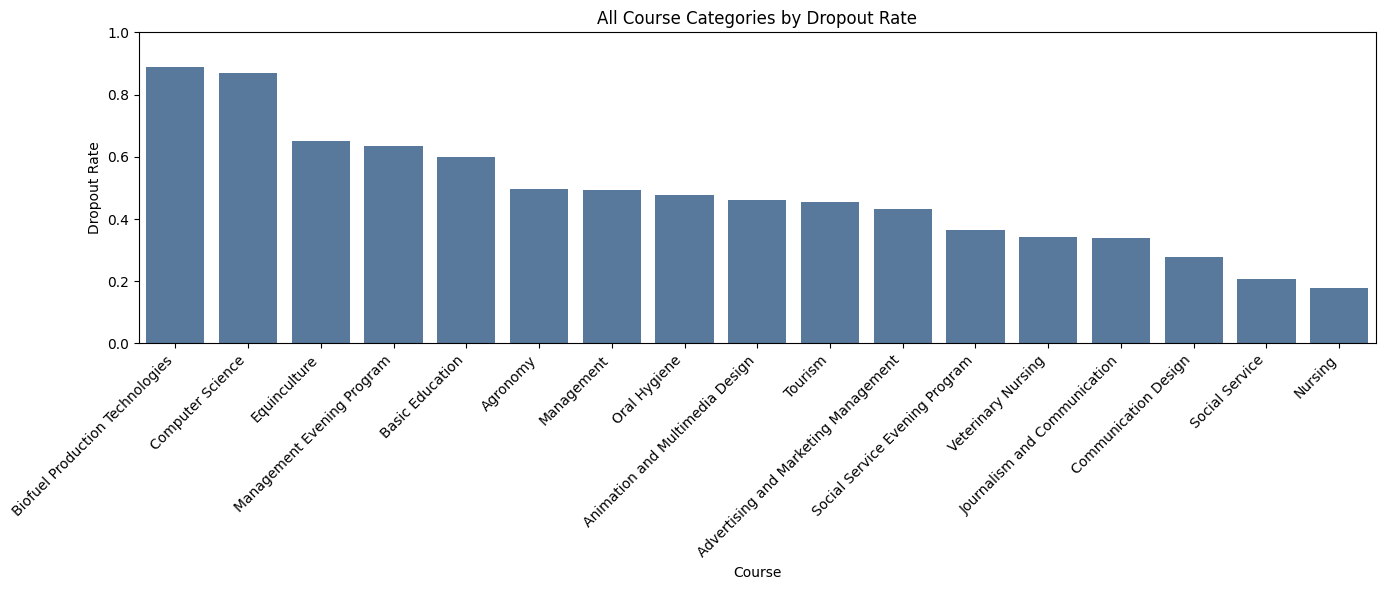


Highest dropout-rate categories: Previous qualification


,Previous qualification,count,dropout_rate
0,Basic education 3rd cycle,149,0.697987
1,Other 11th year schooling,39,0.666667
2,Higher education - degree,122,0.614754
3,Technological specialization course,164,0.420732
4,Higher education - degree 1st cycle,34,0.411765
5,Secondary education,3019,0.357072


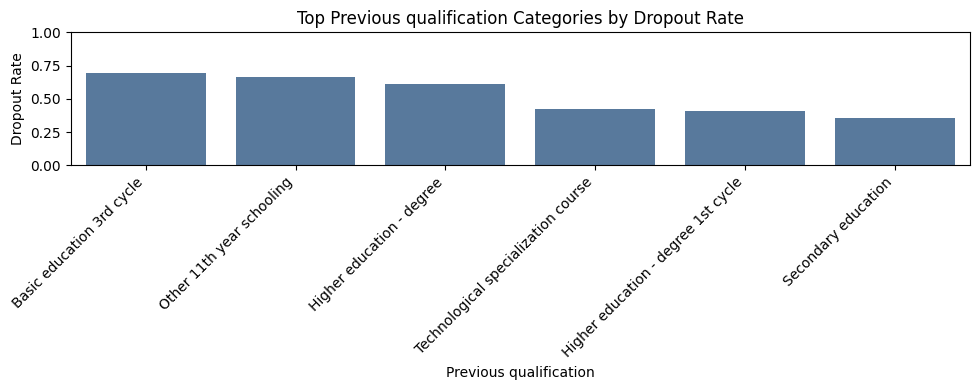


Highest dropout-rate categories: Mother's qualification


,Mother's qualification,count,dropout_rate
0,Unknown education level,127,0.755906
1,Other 11th year schooling,39,0.564103
2,Basic education 1st cycle,840,0.455952
3,Higher education - degree,337,0.412463
4,Basic education 3rd cycle,777,0.348777
5,Secondary education,865,0.346821
6,Higher education - bachelor's degree,60,0.333333
7,Basic education 2nd cycle,471,0.297240
8,Higher education - master's degree,34,0.235294


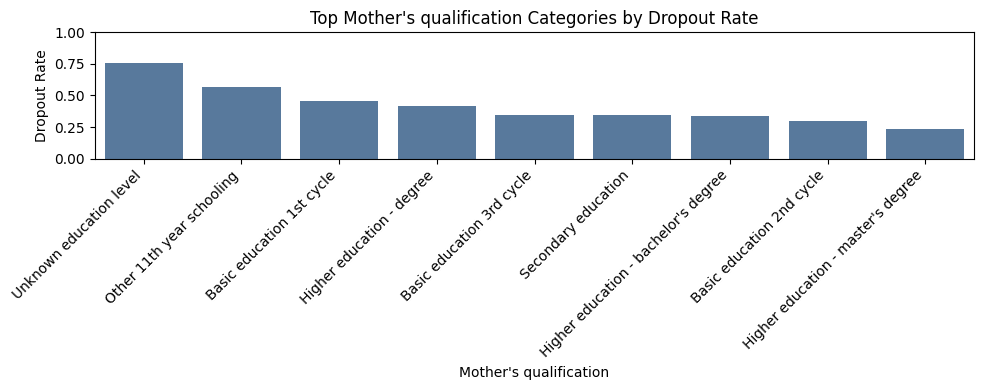


Highest dropout-rate categories: Father's qualification


,Father's qualification,count,dropout_rate
0,Unknown education level,109,0.743119
1,Higher education - bachelor's degree,43,0.511628
2,Higher education - master's degree,32,0.437500
3,Basic education 1st cycle,1010,0.427723
4,Other 11th year schooling,34,0.411765
5,Higher education - degree,220,0.409091
6,Secondary education,732,0.383880
7,Basic education 3rd cycle,785,0.336306
8,Basic education 2nd cycle,575,0.290435


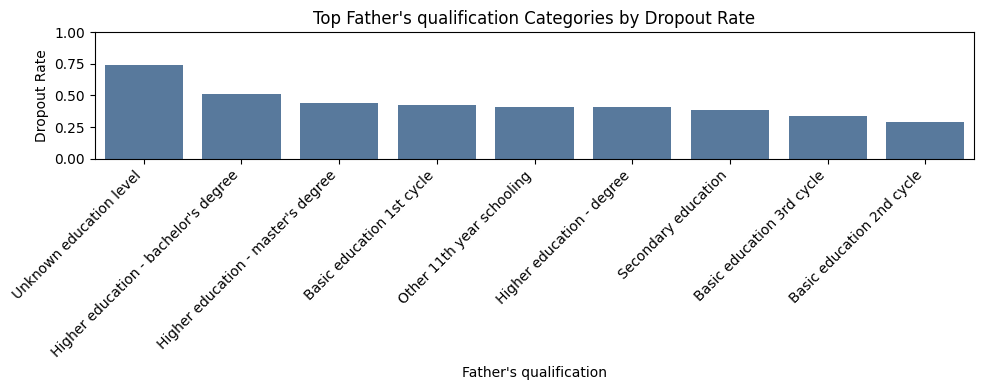

In [42]:
# High-Cardinality Feature Dropout Rate
# For Course, show every category so the full study-program risk pattern is visible.
# For other high-cardinality features, keep only categories with at least 30 records
# and show the top 10 dropout-rate categories to avoid very unstable and crowded plots.

MIN_CATEGORY_COUNT = 30

for col in high_cardinality_categorical_features:
    summary = (
        df_binary
        .assign(Target_encoded=df_binary["Target"].map({"Graduate": 0, "Dropout": 1}))
        .groupby(col)
        .agg(
            count=("Target_encoded", "size"),
            dropout_rate=("Target_encoded", "mean")
        )
        .sort_values("dropout_rate", ascending=False)
    )

    if col == "Course":
        plot_summary = summary.reset_index()
        plot_title = "All Course Categories by Dropout Rate"
        print_title = "All course categories by dropout rate"
        figure_size = (14, 6)
    else:
        plot_summary = summary.query("count >= @MIN_CATEGORY_COUNT").head(10).reset_index()
        plot_title = f"Top {col} Categories by Dropout Rate"
        print_title = f"Highest dropout-rate categories: {col}"
        figure_size = (10, 4)

    print(f"\n{print_title}")
    display(plot_summary)

    plt.figure(figsize=figure_size)
    sns.barplot(
        data=plot_summary,
        x=col,
        y="dropout_rate",
        color="#4C78A8"
    )
    plt.title(plot_title)
    plt.xlabel(col)
    plt.ylabel("Dropout Rate")
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()


### Graphical EDA

These charts visualize class balance, age distribution, categorical feature counts, and the simple age-target correlation used for exploratory interpretation.

In [43]:
# Target Distribution
# Check Graduate vs Dropout balance after removing Enrolled records.
# This matters because accuracy can look acceptable even when Dropout recall is weak.

target_percentage = (
    df_binary["Target"]
    .value_counts(normalize=True)
    .loc[["Graduate", "Dropout"]]
    * 100
)

target_percentage_table = pd.DataFrame({
    "percentage": target_percentage.round(2)
})

target_percentage_table

,percentage
Target,
Graduate,60.85
Dropout,39.15


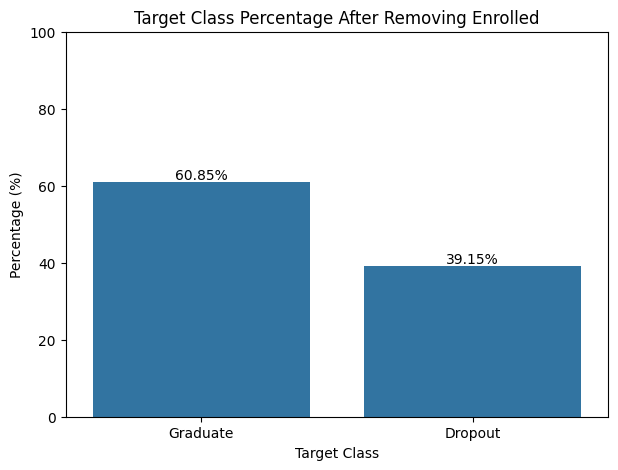

In [44]:
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=target_percentage.index,
    y=target_percentage.values
)

plt.title("Target Class Percentage After Removing Enrolled")
plt.xlabel("Target Class")
plt.ylabel("Percentage (%)")
plt.ylim(0, 100)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.show()

##### Target Distribution Insight

After removing Enrolled records, the dataset contains only Graduate and Dropout classes. Graduate is the larger class, but the imbalance is moderate rather than extreme.

Because Dropout is the risk class, later model evaluation should prioritize recall, precision, F1-score, and confusion matrix interpretation instead of relying on accuracy alone.

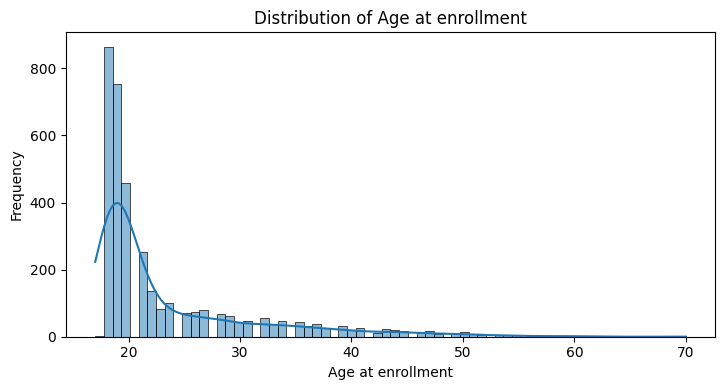

In [45]:
# Continuous Features Histogram
# Plot the distribution of the continuous feature.
n_cols = 2
n_rows = int(np.ceil(len(continuous_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))

axes = axes.flatten()

for i, col in enumerate(continuous_features):
    sns.histplot(
        data=df_binary,
        x=col,
        kde=True,
        ax=axes[i]
    )
    
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

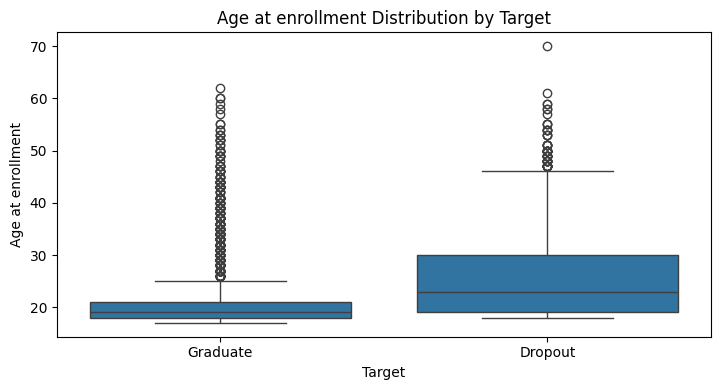

In [46]:
# Continuous Feature by Target
# Compare the continuous feature between Graduate and Dropout records.
n_cols = 2
n_rows = int(np.ceil(len(continuous_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))

axes = axes.flatten()

for i, col in enumerate(continuous_features):
    sns.boxplot(
        data=df_binary,
        x="Target",
        y=col,
        order=["Graduate", "Dropout"],
        ax=axes[i]
    )
    
    axes[i].set_title(f"{col} Distribution by Target")
    axes[i].set_xlabel("Target")
    axes[i].set_ylabel(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

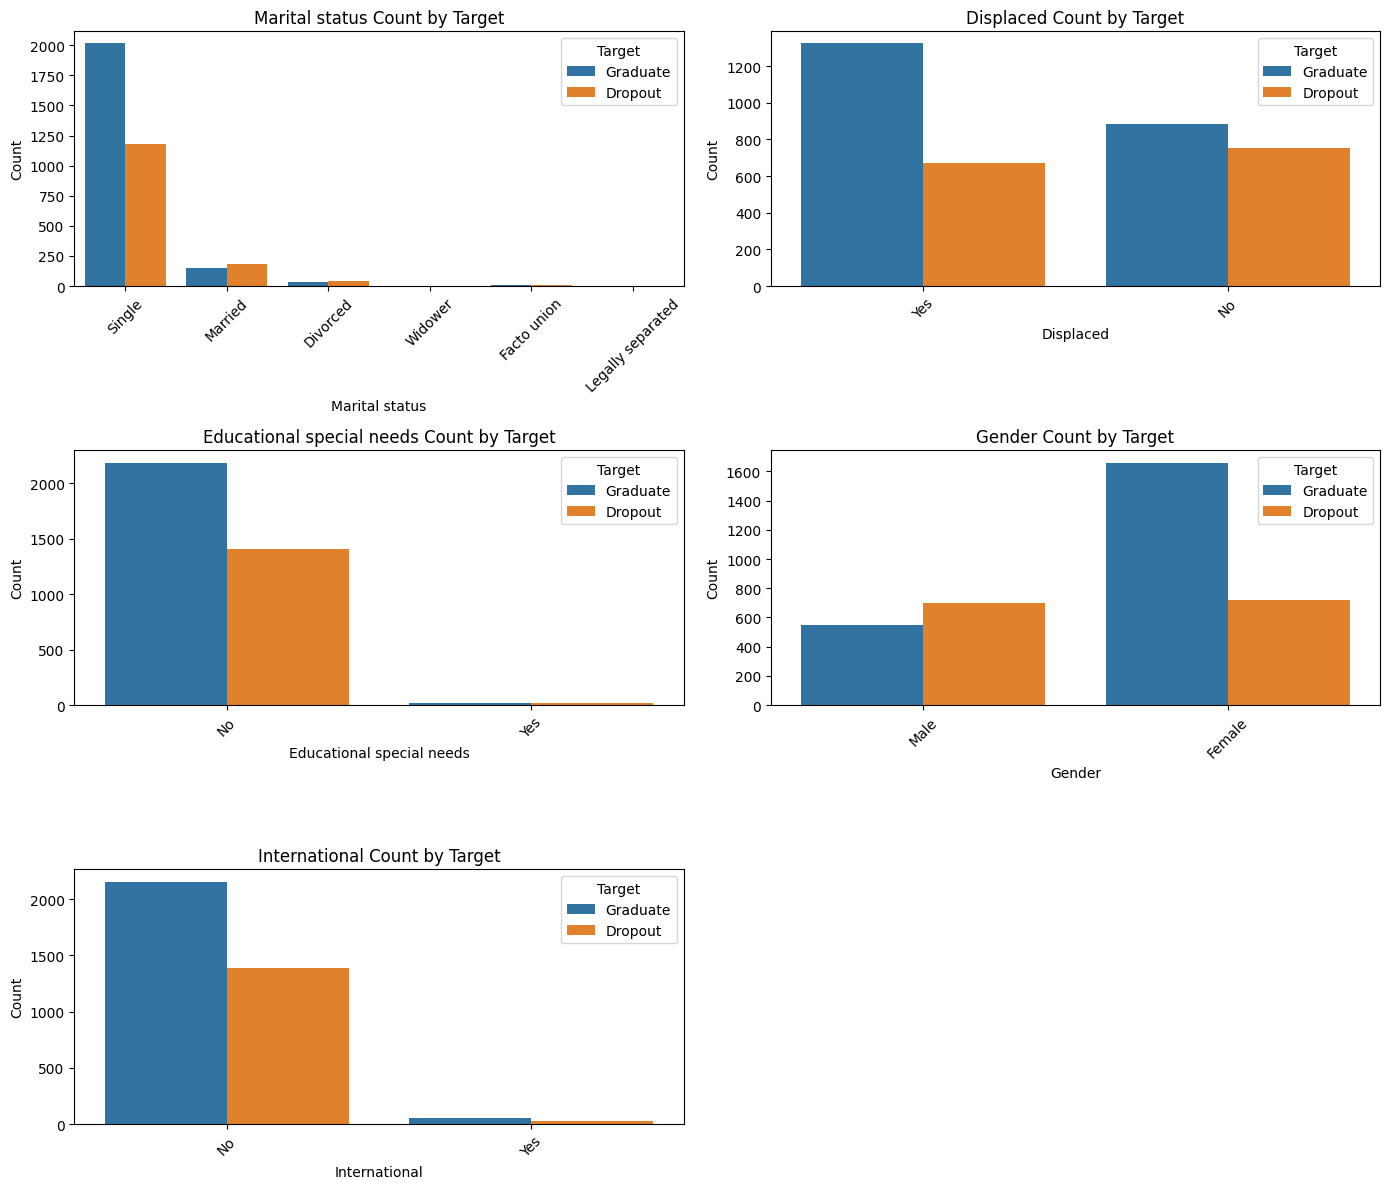

In [47]:
# Low-Cardinality Categorical Feature Countplot
# Plot low-cardinality categorical features against the target.
n_cols = 2
n_rows = int(np.ceil(len(low_cardinality_categorical_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))

axes = np.array(axes).flatten()

for i, col in enumerate(low_cardinality_categorical_features):
    sns.countplot(
        data=df_binary,
        x=col,
        hue="Target",
        hue_order=["Graduate", "Dropout"],
        ax=axes[i]
    )
    
    axes[i].set_title(f"{col} Count by Target")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].legend(title="Target")
    axes[i].tick_params(axis="x", rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

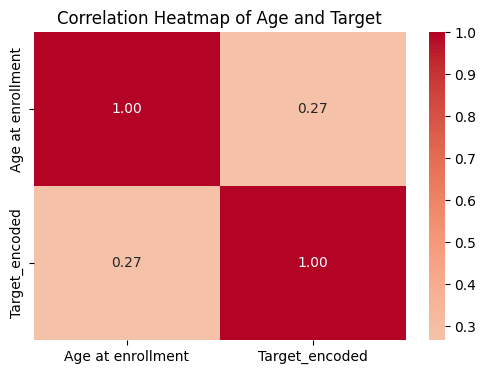

In [48]:
# Continuous Feature Correlation
# Encode the target temporarily only for correlation analysis.
# This is not the final preprocessing target encoding.
corr_data = df_binary[continuous_features].copy()

corr_data["Target_encoded"] = df_binary["Target"].map({
    "Graduate": 0,
    "Dropout": 1
})

continuous_corr = corr_data.corr()

plt.figure(figsize=(6, 4))

sns.heatmap(
    continuous_corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Correlation Heatmap of Age and Target")
plt.show()

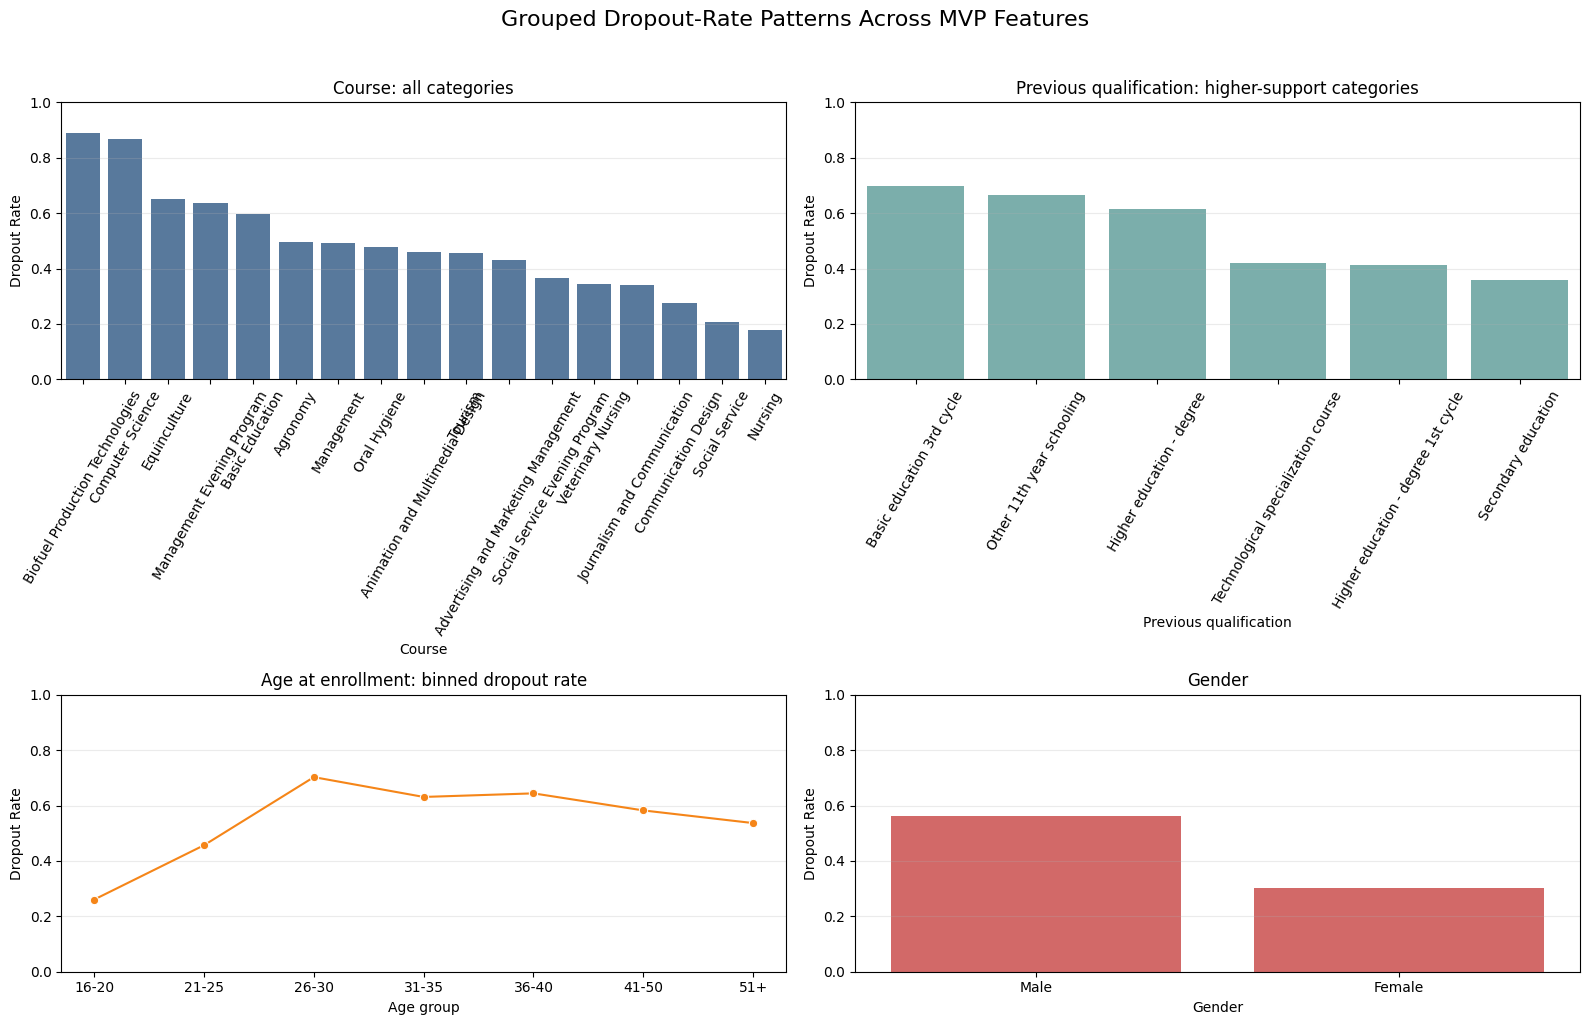

In [49]:
# Non-linear Feature-Target Pattern Summary
# Summarize dropout-rate variation across categorical groups and age bins in one figure.

df_pattern = df_binary.assign(
    Target_encoded=df_binary["Target"].map({"Graduate": 0, "Dropout": 1})
)

age_bins = [15, 20, 25, 30, 35, 40, 50, 80]
age_labels = ["16-20", "21-25", "26-30", "31-35", "36-40", "41-50", "51+"]
df_pattern = df_pattern.assign(
    Age_group=pd.cut(
        df_pattern["Age at enrollment"],
        bins=age_bins,
        labels=age_labels,
        include_lowest=True,
    )
)

course_dropout_rate = (
    df_pattern
    .groupby("Course")
    .agg(count=("Target_encoded", "size"), dropout_rate=("Target_encoded", "mean"))
    .sort_values("dropout_rate", ascending=False)
    .reset_index()
)

previous_qualification_dropout_rate = (
    df_pattern
    .groupby("Previous qualification")
    .agg(count=("Target_encoded", "size"), dropout_rate=("Target_encoded", "mean"))
    .query("count >= @MIN_CATEGORY_COUNT")
    .sort_values("dropout_rate", ascending=False)
    .head(8)
    .reset_index()
)

age_dropout_rate = (
    df_pattern
    .groupby("Age_group", observed=True)
    .agg(count=("Target_encoded", "size"), dropout_rate=("Target_encoded", "mean"))
    .reset_index()
)

gender_dropout_rate = (
    df_pattern
    .groupby("Gender")
    .agg(count=("Target_encoded", "size"), dropout_rate=("Target_encoded", "mean"))
    .sort_values("dropout_rate", ascending=False)
    .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Grouped Dropout-Rate Patterns Across MVP Features", fontsize=16, y=1.02)

sns.barplot(data=course_dropout_rate, x="Course", y="dropout_rate", color="#4C78A8", ax=axes[0, 0])
axes[0, 0].set_title("Course: all categories")
axes[0, 0].set_xlabel("Course")
axes[0, 0].set_ylabel("Dropout Rate")
axes[0, 0].tick_params(axis="x", rotation=60)

sns.barplot(
    data=previous_qualification_dropout_rate,
    x="Previous qualification",
    y="dropout_rate",
    color="#72B7B2",
    ax=axes[0, 1],
)
axes[0, 1].set_title("Previous qualification: higher-support categories")
axes[0, 1].set_xlabel("Previous qualification")
axes[0, 1].set_ylabel("Dropout Rate")
axes[0, 1].tick_params(axis="x", rotation=60)

sns.lineplot(
    data=age_dropout_rate,
    x="Age_group",
    y="dropout_rate",
    marker="o",
    color="#F58518",
    ax=axes[1, 0],
)
axes[1, 0].set_title("Age at enrollment: binned dropout rate")
axes[1, 0].set_xlabel("Age group")
axes[1, 0].set_ylabel("Dropout Rate")

sns.barplot(data=gender_dropout_rate, x="Gender", y="dropout_rate", color="#E45756", ax=axes[1, 1])
axes[1, 1].set_title("Gender")
axes[1, 1].set_xlabel("Gender")
axes[1, 1].set_ylabel("Dropout Rate")

for ax in axes.flat:
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


# EDA Findings

Based on the exploratory data analysis:

- The final MVP uses 10 fixed enrollment/background features: marital status, course, previous qualification, parents' qualification, displaced status, educational special needs, gender, age at enrollment, and international status.
- `Enrolled` records are removed so the project focuses on binary classification between Graduate and Dropout.
- The readable raw full-feature dataset saved to `data/processed/raw_features_readable.csv` contains all 4424 rows and 35 original columns, with available categorical codes converted to readable labels.
- The readable MVP dataset saved to `data/processed/mvp_features_readable.csv` contains 3630 rows and 11 columns after removing Enrolled.
- `Course` shows strong dropout-rate differences across study programs, including higher-risk categories such as Computer Science, Equinculture, Management Evening Program, Basic Education, and Agronomy.
- `Previous qualification`, `Mother's qualification`, and `Father's qualification` show meaningful category-level differences, so they are kept as early background and academic-path signals.
- `Gender` and `Age at enrollment` show visible differences between Graduate and Dropout groups. These are treated as observed associations, not causal explanations.
- Grouped dropout-rate plots for Course, Previous qualification, age bins, and Gender show non-flat feature-target patterns, supporting comparison with non-linear models alongside Logistic Regression.
- Marital status, displaced status, educational special needs, and international status are kept because they are early, understandable background variables that may add supporting signal.
- Semester academic performance, post-acceptance/admin variables, macroeconomic variables, application mode/order, occupation variables, and nationality are excluded to reduce leakage and keep the app input simple.
- The next stage uses these same 10 features for preprocessing, threshold-tuned Random Forest, comparison models, saved artifacts, and the Streamlit app.
